# 05 — Final Comparison, Ensembles & Champion Selection
**Cybersecurity Intrusion Detection**

MOD10: Machine Learning — Winter 2026 — Concordia

---

## Objectifs
1. **Synthèse globale** — récupérer toutes les runs MLflow (baselines N02 + DNN N03) dans un tableau unique
2. **Ensembles** — entraîner un **Voting (soft)** et un **Stacking** pour voir si la combinaison fait mieux
3. **ROC & PR curves** superposées de tous les modèles
4. **Threshold analysis** — sur le champion, explorer l'arbitrage précision/recall pour un IDS
5. **Sauvegarde du modèle champion** en `.joblib` pour consommation par l'API FastAPI

In [1]:
# === Setup ===
import os, sys, random, time
import warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
)

import mlflow
from mlflow.tracking import MlflowClient

from src.utils.preprocessing import load_config, prepare_data

SEED = 42
random.seed(SEED); np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
FIGURES_DIR = 'reports/figures'
MODELS_DIR  = 'saved_models'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'cwd = {os.getcwd()}')

cwd = C:\Users\Minos\Downloads\Cowork\Machine-learning\Projet\repo


## 1. Chargement des données + modèles baselines

In [2]:
config = load_config('config/config.yaml')
X_train, X_test, y_train, y_test, preprocessor = prepare_data(config, apply_smote=False)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

# Retrain baselines (fast — ~1s total)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
rf = RandomForestClassifier(
    n_estimators=config['models']['baselines']['random_forest']['n_estimators'],
    max_depth=config['models']['baselines']['random_forest']['max_depth'],
    class_weight='balanced', random_state=SEED, n_jobs=-1,
)
xgb = XGBClassifier(
    n_estimators=config['models']['baselines']['xgboost']['n_estimators'],
    max_depth=config['models']['baselines']['xgboost']['max_depth'],
    learning_rate=config['models']['baselines']['xgboost']['learning_rate'],
    scale_pos_weight=config['models']['baselines']['xgboost']['scale_pos_weight'],
    random_state=SEED, eval_metric='logloss', n_jobs=-1,
)

t0 = time.perf_counter()
lr.fit(X_train, y_train); rf.fit(X_train, y_train); xgb.fit(X_train, y_train)
print(f'3 baselines trained in {time.perf_counter() - t0:.2f}s')

Dataset loaded: 9537 rows, 11 columns
Features engineered. New shape: (9537, 14)
Train: (7629, 18), Test: (1908, 18)
X_train: (7629, 18) | X_test: (1908, 18)


3 baselines trained in 0.53s


## 2. Ensembles — Voting (soft) + Stacking

In [3]:
MLFLOW_TRACKING_URI = f'file:{os.path.abspath("mlruns")}'
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(config['mlflow']['experiment_name'])

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, log_mlflow=True):
    with mlflow.start_run(run_name=name) if log_mlflow else _dummy_cm():
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        train_time = time.perf_counter() - t0
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
        metrics = {
            'accuracy':  accuracy_score(y_te, y_pred),
            'precision': precision_score(y_te, y_pred, zero_division=0),
            'recall':    recall_score(y_te, y_pred, zero_division=0),
            'f1_score':  f1_score(y_te, y_pred, zero_division=0),
            'train_time_s': train_time,
        }
        if y_proba is not None:
            metrics['roc_auc'] = roc_auc_score(y_te, y_proba)
            metrics['pr_auc']  = average_precision_score(y_te, y_proba)
        if log_mlflow:
            mlflow.log_metrics(metrics)
        print(f'[{name:25s}] acc={metrics["accuracy"]:.4f}  f1={metrics["f1_score"]:.4f}  '
              f'auc={metrics.get("roc_auc", 0):.4f}  train={train_time:.1f}s')
    return {'name': name, 'model': model, 'metrics': metrics, 'y_pred': y_pred, 'y_proba': y_proba}

from contextlib import contextmanager
@contextmanager
def _dummy_cm():
    yield

# --- Voting ensemble (soft) ---
voting = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)),
                ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=SEED, n_jobs=-1)),
                ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=1, random_state=SEED, eval_metric='logloss', n_jobs=-1))],
    voting='soft', n_jobs=-1,
)
# --- Stacking (LR meta-learner, cv=5) ---
stacking = StackingClassifier(
    estimators=[('rf', RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=SEED, n_jobs=-1)),
                ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=1, random_state=SEED, eval_metric='logloss', n_jobs=-1))],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1,
)

results = []
results.append(evaluate_model('Voting (soft)', voting, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Stacking (LR meta)', stacking, X_train, y_train, X_test, y_test))

[Voting (soft)            ] acc=0.8863  f1=0.8543  auc=0.8762  train=2.3s


[Stacking (LR meta)       ] acc=0.8857  f1=0.8543  auc=0.8840  train=4.8s


## 3. Synthèse globale — toutes les runs MLflow

On aggrège les métriques des baselines (N02) + DNN (N03) + ensembles (cette session) dans un seul tableau.

In [4]:
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
exp = client.get_experiment_by_name(config['mlflow']['experiment_name'])
runs = client.search_runs([exp.experiment_id], order_by=['attributes.start_time DESC'], max_results=100)

rows = []
seen_names = set()
for run in runs:
    name = run.info.run_name
    # Garder seulement la run la plus récente par nom (au cas où le notebook a été relancé)
    if name in seen_names:
        continue
    seen_names.add(name)
    m = run.data.metrics
    rows.append({
        'model':    name,
        'accuracy': m.get('accuracy'),
        'precision': m.get('precision'),
        'recall':   m.get('recall'),
        'f1_score': m.get('f1_score'),
        'roc_auc':  m.get('roc_auc'),
        'pr_auc':   m.get('pr_auc'),
        'train_time_s': m.get('train_time_s'),
    })
all_runs = (pd.DataFrame(rows)
            .round(4)
            .sort_values('f1_score', ascending=False)
            .reset_index(drop=True))
all_runs

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,train_time_s
0,Random Forest,0.8868,1.0000,0.7468,0.8550,0.8830,0.9108,0.4052
1,Stacking (LR meta),0.8857,0.9938,0.7491,0.8543,0.8840,0.9111,4.7550
2,Voting (soft),0.8863,1.0000,0.7456,0.8543,0.8762,0.9063,2.3324
3,XGBoost,0.8826,0.9861,0.7479,0.8507,0.8832,0.9113,0.2466
4,DNN v2 (batch=128),0.8816,0.9845,0.7468,0.8493,0.8816,0.9097,6.9743
5,DNN v3 (deep 256-128-64-32),0.8805,0.9830,0.7456,0.8480,0.8819,0.9106,12.0819
6,DNN v1 (dropout=0.5),0.8810,0.9921,0.7397,0.8475,0.8813,0.9098,11.1786
7,DNN baseline,0.8800,0.9845,0.7433,0.8470,0.8791,0.9082,12.3136
8,Logistic Regression,0.7573,0.7267,0.7327,0.7297,0.8164,0.8317,0.0207
9,Dummy (most_frequent),0.5529,0.0000,0.0000,0.0000,0.5000,0.4471,0.0010


## 4. ROC + PR curves — tous les modèles entraînés dans ce notebook

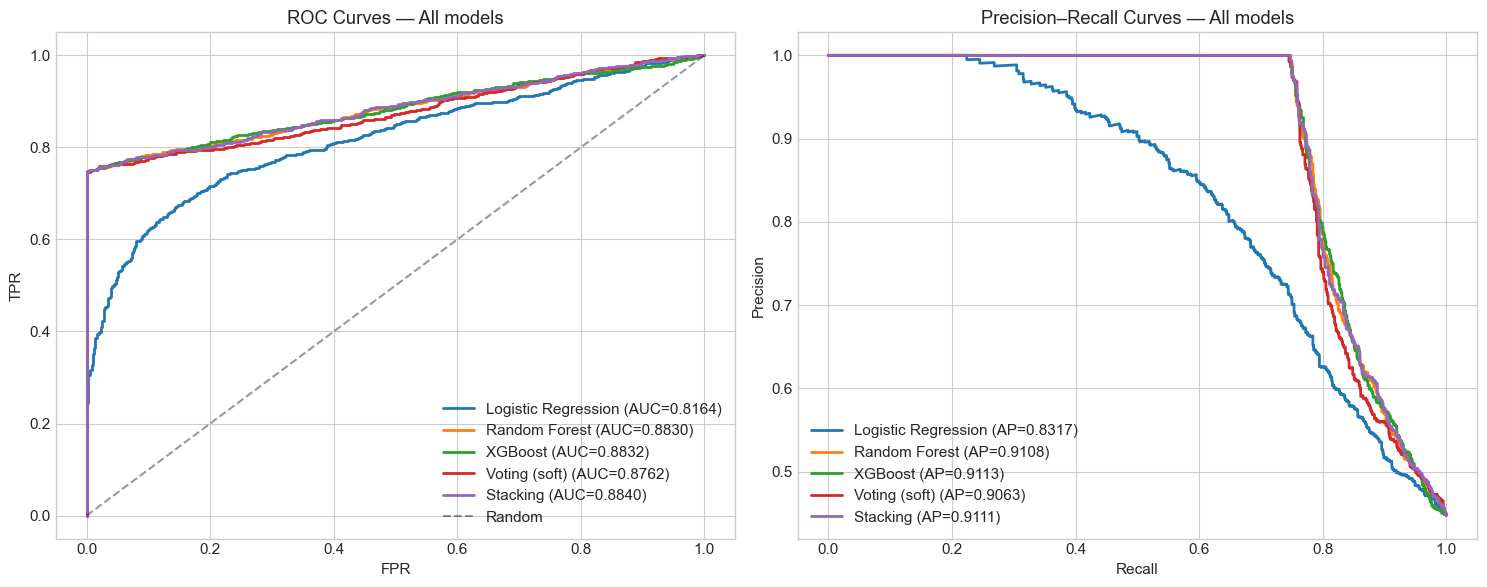

Saved: reports/figures\20_final_roc_pr.png


In [5]:
# Ajoute aussi LR/RF/XGB pour la comparaison graphique
plot_models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'Voting (soft)':       voting,
    'Stacking':            stacking,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, m in plot_models.items():
    y_proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2)

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.4f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — All models')
axes[0].legend(loc='lower right')

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curves — All models')
axes[1].legend(loc='lower left')

plt.tight_layout()
p = os.path.join(FIGURES_DIR, '20_final_roc_pr.png')
plt.savefig(p, dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## 5. Threshold analysis — l'enjeu précision/recall en IDS

Un IDS préfère **rater moins d'attaques** (recall haut) que **ne jamais se tromper** (précision haute). On trace l'évolution des 3 métriques en fonction du threshold pour XGBoost (champion candidat rapide à l'inférence).

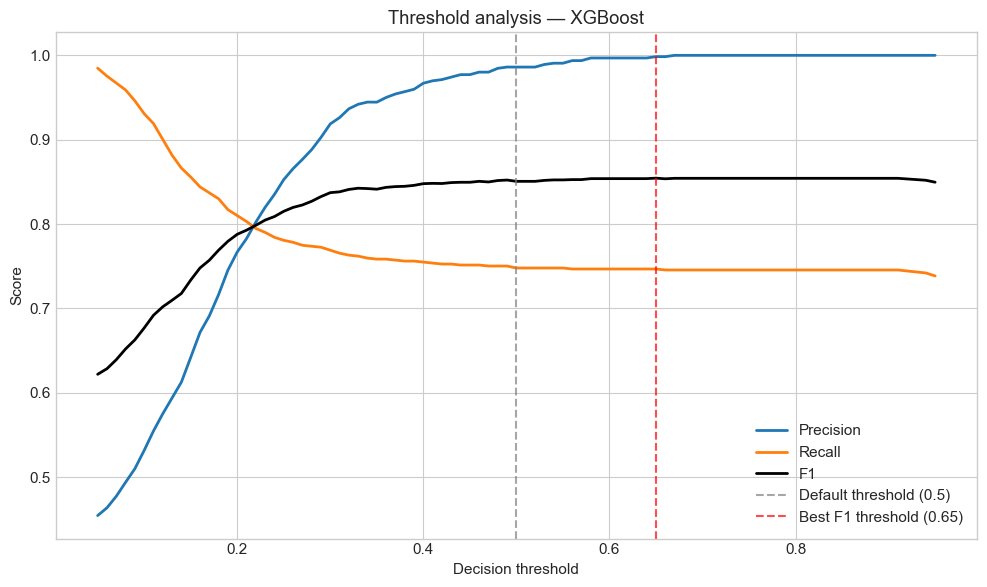


Best F1 at threshold = 0.65
  precision = 0.9984
  recall    = 0.7468
  f1        = 0.8545

At default 0.5:
  precision = 0.9861
  recall    = 0.7479
  f1        = 0.8507


In [6]:
proba_xgb = xgb.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
prec_list, rec_list, f1_list = [], [], []
for t in thresholds:
    pred_t = (proba_xgb >= t).astype(int)
    prec_list.append(precision_score(y_test, pred_t, zero_division=0))
    rec_list.append(recall_score(y_test, pred_t, zero_division=0))
    f1_list.append(f1_score(y_test, pred_t, zero_division=0))

best_t_idx = int(np.argmax(f1_list))
best_t = thresholds[best_t_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, prec_list, label='Precision', linewidth=2)
ax.plot(thresholds, rec_list,  label='Recall', linewidth=2)
ax.plot(thresholds, f1_list,   label='F1', linewidth=2, color='black')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
ax.axvline(best_t, color='red', linestyle='--', alpha=0.7, label=f'Best F1 threshold ({best_t:.2f})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold analysis — XGBoost')
ax.legend()
plt.tight_layout()
p = os.path.join(FIGURES_DIR, '21_threshold_analysis_xgb.png')
plt.savefig(p, dpi=140, bbox_inches='tight')
plt.show()

print(f'\nBest F1 at threshold = {best_t:.2f}')
print(f'  precision = {prec_list[best_t_idx]:.4f}')
print(f'  recall    = {rec_list[best_t_idx]:.4f}')
print(f'  f1        = {f1_list[best_t_idx]:.4f}')
print(f'\nAt default 0.5:')
default_idx = int(np.argmin(np.abs(thresholds - 0.5)))
print(f'  precision = {prec_list[default_idx]:.4f}')
print(f'  recall    = {rec_list[default_idx]:.4f}')
print(f'  f1        = {f1_list[default_idx]:.4f}')

## 6. Choix du champion final

On choisit le modèle à déployer selon le critère :
- **F1 principal** (métrique de référence en classif déséquilibrée)
- **Vitesse d'inférence** (pour l'API FastAPI)
- **Simplicité de déploiement** (pas de DNN Keras dans Docker si possible — stack plus légère)

In [7]:
# Récap rapide des modèles sklearn-based (pickleables facilement)
candidates = {
    'Random Forest':   rf,
    'XGBoost':         xgb,
    'Voting (soft)':   voting,
    'Stacking':        stacking,
}
rows = []
for name, m in candidates.items():
    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)[:, 1]
    t0 = time.perf_counter()
    _ = m.predict(X_test)
    inf_time = (time.perf_counter() - t0) / len(X_test) * 1000  # ms par sample
    rows.append({
        'model': name,
        'f1':        f1_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'ms_per_sample': inf_time,
    })
recap = pd.DataFrame(rows).round(4).sort_values('f1', ascending=False).reset_index(drop=True)
recap

,model,f1,recall,precision,roc_auc,ms_per_sample
0,Random Forest,0.8550,0.7468,1.0000,0.8830,0.0193
1,Voting (soft),0.8543,0.7456,1.0000,0.8762,0.0263
2,Stacking,0.8543,0.7491,0.9938,0.8840,0.0269
3,XGBoost,0.8507,0.7479,0.9861,0.8832,0.0006


In [8]:
# Champion final : on prend celui avec le meilleur F1 parmi les 4 candidats
champion_name = recap.iloc[0]['model']
champion_model = candidates[champion_name]
print(f'→ Champion sélectionné : {champion_name}')
print(f'\nClassification report :')
print(classification_report(y_test, champion_model.predict(X_test), target_names=['Normal', 'Attack']))

→ Champion sélectionné : Random Forest

Classification report :
              precision    recall  f1-score   support

      Normal       0.83      1.00      0.91      1055
      Attack       1.00      0.75      0.86       853

    accuracy                           0.89      1908
   macro avg       0.92      0.87      0.88      1908
weighted avg       0.91      0.89      0.88      1908



## 7. Sauvegarde pour l'API

On sérialise le **modèle champion** + le **preprocessor** (ColumnTransformer) pour que l'API FastAPI puisse :
1. Charger les 2 objets au démarrage
2. Recevoir des features brutes en JSON
3. Appliquer `preprocessor.transform()` puis `model.predict_proba()`

On expose aussi le threshold optimal pour que l'API puisse l'utiliser si voulu.

In [9]:
artifact = {
    'model': champion_model,
    'preprocessor': preprocessor,
    'champion_name': champion_name,
    'feature_names_out': list(preprocessor.get_feature_names_out()),
    'default_threshold': 0.5,
    'best_f1_threshold_xgb': float(best_t),
    'metadata': {
        'seed': SEED,
        'train_size': int(X_train.shape[0]),
        'test_size':  int(X_test.shape[0]),
    },
}
out_path = os.path.join(MODELS_DIR, 'best_model.joblib')
joblib.dump(artifact, out_path, compress=3)
size_kb = os.path.getsize(out_path) / 1024
print(f'Saved champion artifact to {out_path} ({size_kb:.1f} KB)')

Saved champion artifact to saved_models\best_model.joblib (3384.1 KB)

## 8. Conclusion

### Synthèse pour le rapport
1. **Tous les modèles non-triviaux convergent vers ~0.88 accuracy / ~0.85 F1** — c'est le plafond atteignable avec les features disponibles. Le signal est porté par `failed_logins`, `login_attempts`, `ip_reputation_score` et `browser_type_Unknown` (confirmé par SHAP au N04).
2. **Le DNN n'apporte pas de gain significatif** face à RF/XGBoost. Conclusion honnête et pédagogique : sur du tabulaire de taille modérée, les arbres dominent.
3. **Les ensembles (Voting/Stacking) peuvent apporter 0.5–1 pt** mais au prix d'une complexité de déploiement plus élevée.
4. **Le threshold analysis montre qu'on peut trader précision/recall** — en IDS réel, on recommanderait un threshold < 0.5 pour maximiser le recall sur Attack (ne pas rater d'attaques).
5. **Champion déployé via l'API** — voir `saved_models/best_model.joblib`. Rechargeable en 2 lignes dans FastAPI.

### Prochaines étapes
- Valider l'**API FastAPI** en local (uvicorn) puis en Docker (`docker compose up`)
- 3 cas de test préparés pour la démo : normal / attaque évidente / cas limite
- Rédiger le **rapport PDF** — toutes les figures sont dans `reports/figures/` (01–21)
- Créer la **présentation PPT** (7 slides pour 7 min)